In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy import signal
import h5py
import os

sys.path.append(os.path.abspath('.'))
from SPEC2VEC.src.utils.data_preparations import *
from SPEC2VEC.src.utils.spectograms_lib import * 
from SPEC2VEC.src.utils.noise_lib import * 
from SPEC2VEC.src.utils.complex_waveform_models import Simulator
from jwave.geometry import *

#### Figure 1, Simple Synthetics, Comparison Between Additive and Multiplicative Signals

In [12]:
save_fig_path = 'PRJ_GIS_QA/figs/forpaper/data_figures'

In [13]:
fs = 1000  
T = 2     
w = np.array([50,15])
a = np.array([1,1])
L = int(fs*T)

# 1. Linear Additive Signal + Gaussian Noise
t1, additive_signal = gen_additive_synthetic_signal(fs,T,w,a) 
additive_signal += white_noise_series(L,0.5)
f, additive_spec = signal_spectra(additive_signal,fs,L)

# 2. Nonlinear Multiplicative Signal
t2, multiplicative_signal = gen_multiplicative_synthetic_signal(fs,T,w,a,2) 
multiplicative_signal += white_noise_series(L,0.5)
f, mul_spec = signal_spectra(multiplicative_signal,fs,L)


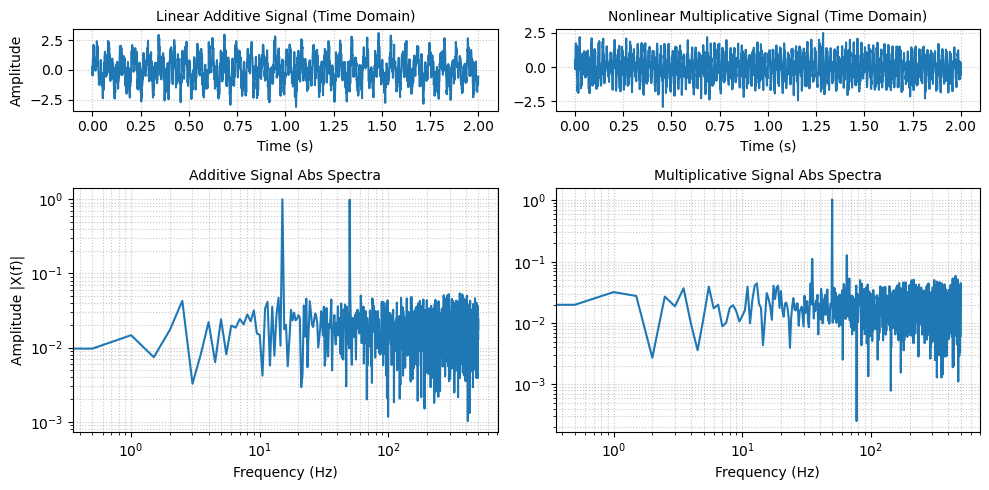

In [14]:
plt_savename = 'linear_mult_ts_singals.svg'

fig, axs = plt.subplots(2, 2, figsize=(10, 5), gridspec_kw={'height_ratios': [1, 3]})

axs[0, 0].plot(t1, additive_signal)
axs[0, 0].set_title('Linear Additive Signal (Time Domain)', fontsize=10)
axs[0, 0].set_xlabel('Time (s)', fontsize=10)
axs[0, 0].set_ylabel('Amplitude', fontsize=10)
axs[0, 0].grid(True, linestyle=':', alpha=0.7)

axs[0, 1].plot(t2, multiplicative_signal)
axs[0, 1].set_title('Nonlinear Multiplicative Signal (Time Domain)', fontsize=10)
axs[0, 1].set_xlabel('Time (s)', fontsize=10)
axs[0, 1].grid(True, linestyle=':', alpha=0.7)

axs[1, 0].plot(f, additive_spec)
axs[1, 0].set_title('Additive Signal Abs Spectra', fontsize=10)
axs[1, 0].set_xlabel('Frequency (Hz)', fontsize=10)
axs[1, 0].set_ylabel('Amplitude |X(f)|', fontsize=10)
axs[1, 0].set_xscale('log') 
axs[1, 0].set_yscale('log')
axs[1, 0].grid(True, which="both", linestyle=':', alpha=0.7) 

axs[1, 1].plot(f, mul_spec)
axs[1, 1].set_title('Multiplicative Signal Abs Spectra', fontsize=10)
axs[1, 1].set_xlabel('Frequency (Hz)', fontsize=10)
axs[1, 1].set_xscale('log') 
axs[1, 1].set_yscale('log') 
axs[1, 1].grid(True, which="both", linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(save_fig_path,plt_savename), dpi=300)
plt.show()

#### Figure 1, Simple Synthetics, Noise Spectra

In [19]:
fs = 1000  
T = 2     
w = np.array([50,15])
a = np.array([1,1])
L = int(fs*T)

# Generate Colored Noise
gen = ColoredNoiseGenerator(L)
red_noise = gen.brownian()
violet_noise = gen.violet()

# Linear Additive Signal + Color Noise
t1, additive_signal = gen_additive_synthetic_signal(fs,T,w,a) 
additive_signal += red_noise
additive_signal += violet_noise

# 2. Nonlinear Multiplicative Signal
t2, multiplicative_signal = gen_multiplicative_synthetic_signal(fs,T,w,a,2) 
multiplicative_signal += red_noise
multiplicative_signal += violet_noise

# Spectral of All Signals
f, additive_col_spec = signal_spectra(additive_signal,fs,L)
f, mul_spec = signal_spectra(multiplicative_signal,fs,L)
f, red_spec = signal_spectra(red_noise,fs,L)
f, violet_spec = signal_spectra(violet_noise,fs,L)


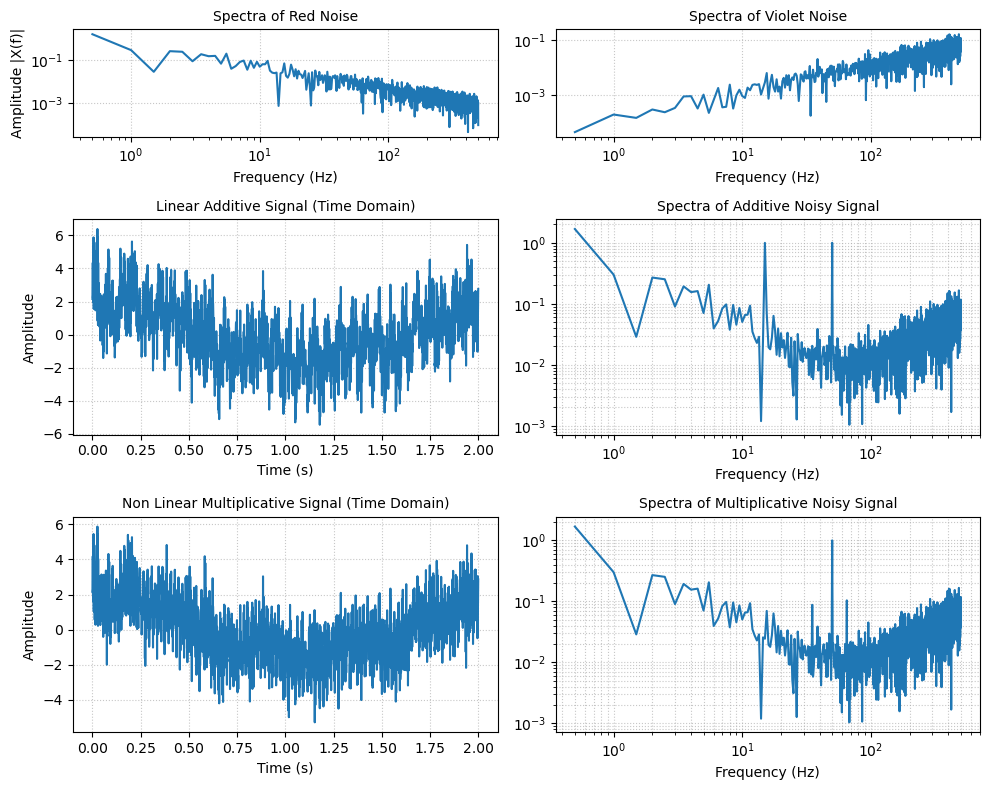

In [23]:
plt_savename = 'noise_spectras_exmpl.svg'

fig, axs = plt.subplots(3, 2, figsize=(10, 8), gridspec_kw={'height_ratios': [1, 2, 2]})

axs[0, 0].plot(f[1:-1], red_spec[1:-1])
axs[0, 0].set_title('Spectra of Red Noise', fontsize=10)
axs[0, 0].set_xlabel('Frequency (Hz)', fontsize=10)
axs[0, 0].set_ylabel('Amplitude |X(f)|', fontsize=10)
axs[0, 0].set_xscale('log') 
axs[0, 0].set_yscale('log')
axs[0, 0].grid(True, linestyle=':', alpha=0.7)

axs[0, 1].plot(f[1:-1], violet_spec[1:-1])
axs[0, 1].set_title('Spectra of Violet Noise', fontsize=10)
axs[0, 1].set_xlabel('Frequency (Hz)', fontsize=10)
axs[0, 1].set_xscale('log') 
axs[0, 1].set_yscale('log')
axs[0, 1].grid(True, linestyle=':', alpha=0.7)

axs[1, 0].plot(t1, additive_signal)
axs[1, 0].set_title('Linear Additive Signal (Time Domain)', fontsize=10)
axs[1, 0].set_xlabel('Time (s)', fontsize=10)
axs[1, 0].set_ylabel('Amplitude', fontsize=10)
axs[1, 0].grid(True, linestyle=':', alpha=0.7)

axs[1, 1].plot(f[1:-1], additive_col_spec[1:-1])
axs[1, 1].set_title('Spectra of Additive Noisy Signal', fontsize=10)
axs[1, 1].set_xlabel('Frequency (Hz)', fontsize=10)
axs[1, 1].set_xscale('log') 
axs[1, 1].set_yscale('log') 
axs[1, 1].grid(True, which="both", linestyle=':', alpha=0.7)

axs[2, 0].plot(t2, multiplicative_signal)
axs[2, 0].set_title('Non Linear Multiplicative Signal (Time Domain)', fontsize=10)
axs[2, 0].set_xlabel('Time (s)', fontsize=10)
axs[2, 0].set_ylabel('Amplitude', fontsize=10)
axs[2, 0].grid(True, linestyle=':', alpha=0.7)

axs[2, 1].plot(f[1:-1], mul_spec[1:-1])
axs[2, 1].set_title('Spectra of Multiplicative Noisy Signal', fontsize=10)
axs[2, 1].set_xlabel('Frequency (Hz)', fontsize=10)
axs[2, 1].set_xscale('log') 
axs[2, 1].set_yscale('log') 
axs[2, 1].grid(True, which="both", linestyle=':', alpha=0.7)


plt.tight_layout()
plt.savefig(os.path.join(save_fig_path,plt_savename), dpi=300)
plt.show()

#### Figure 3, Complex Synthetic - Graph with Acoustic Modeling

Set density data for Sound : True, Density : False
Sensors parameters:  {'positions': typing.Tuple[tuple]}


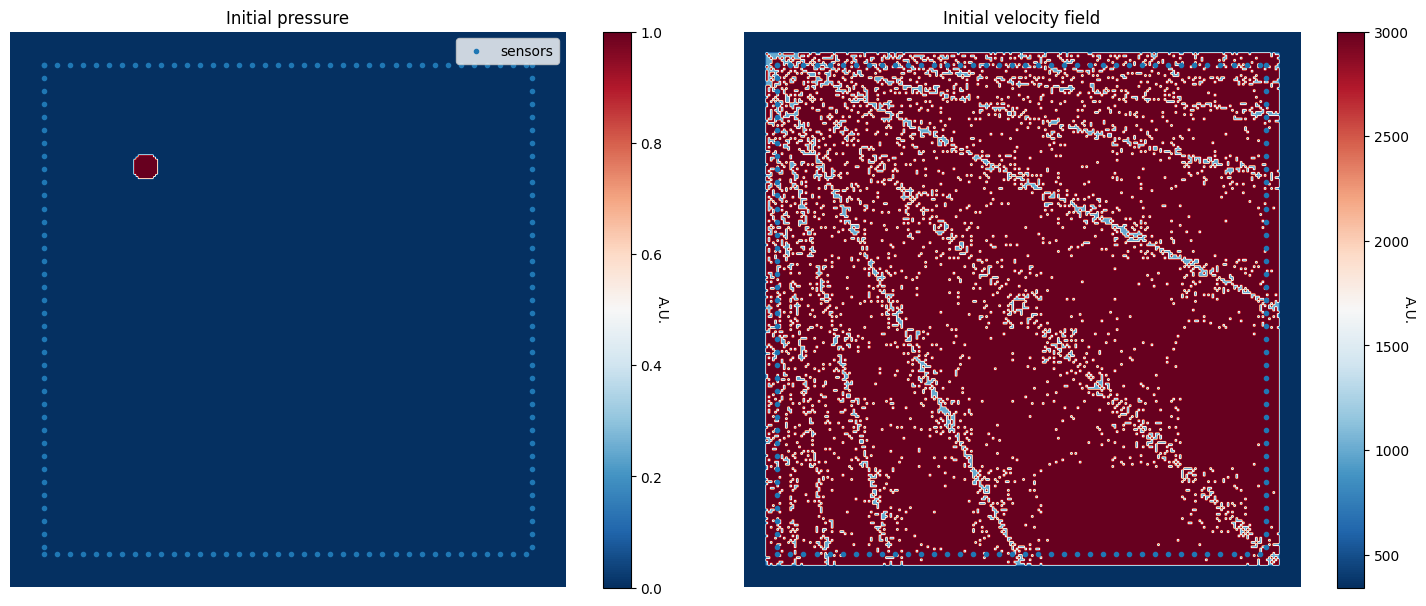

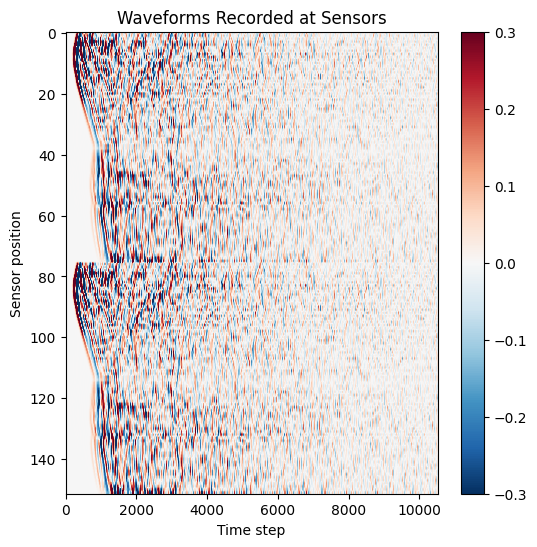

In [37]:
domain = Domain((128*2.5+10, 128*2.5+10), (1, 1))
simulator = Simulator() 
simulator.run_basic_setup()
sensors_data = simulator.compiled_simulator_sensors()
simulator.plot_sensors_data(sensors_data,vmax=0.3,vmin=-0.3,save_me=False)

## Test with Additional setups to check how the wave behaves without damage and if any reverberations are visible.
#(pml_size=20, num_air_grid=1) #simulator.p_vals=0.1

#### Figure 3a,b, Complex Synthetic-Spatail with Acoustic Modeling

Set density data for Sound : True, Density : False
Sensors parameters:  {'positions': typing.Tuple[tuple]}


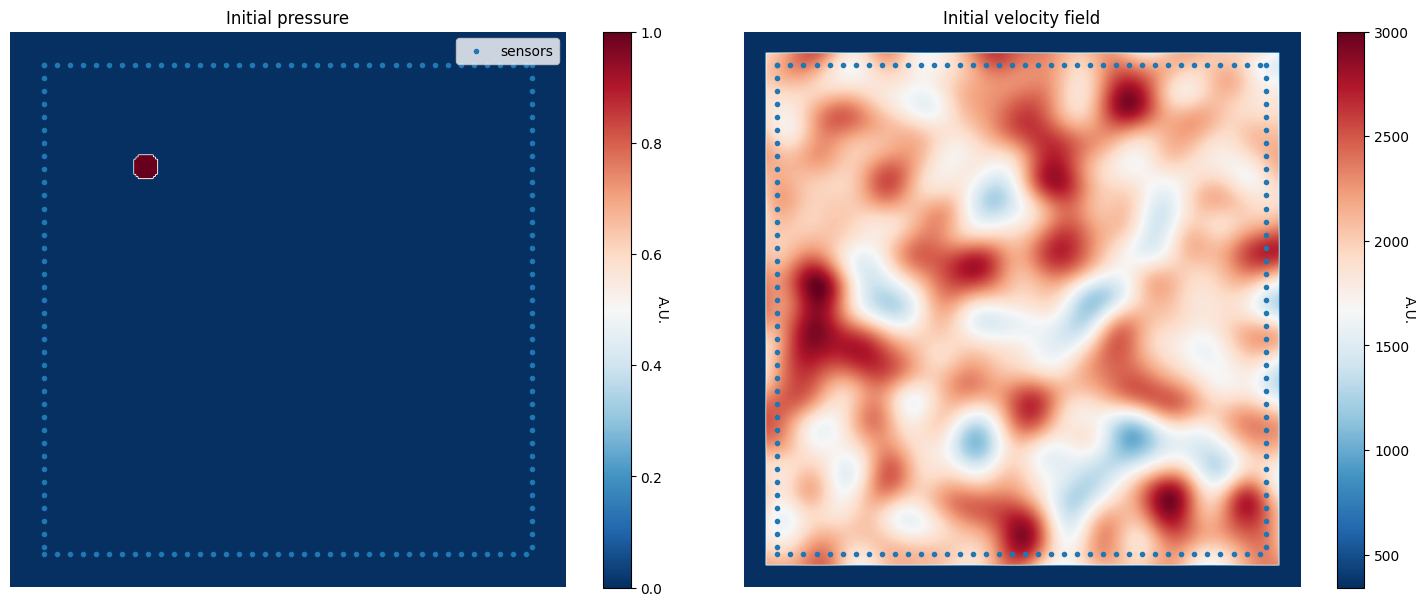

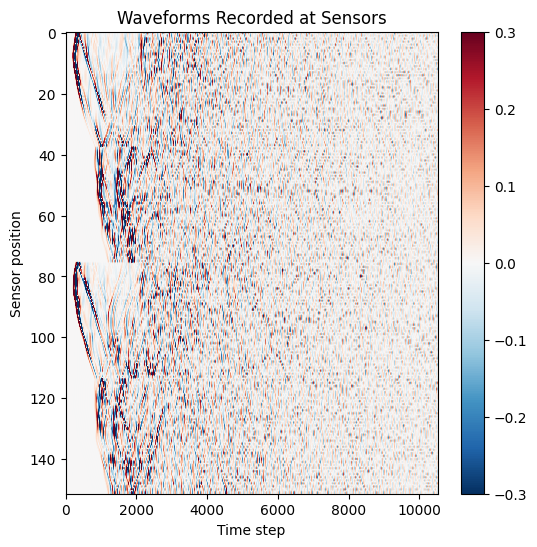

In [38]:
domain = Domain((128*2.5+10, 128*2.5+10), (1, 1))
simulator = Simulator()
simulator.run_basic_setup(field_type='Spatial')
sensors_data = simulator.compiled_simulator_sensors()
simulator.plot_sensors_data(sensors_data,vmax=0.3,vmin=-0.3,save_me=False)